In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
%matplotlib inline

import plotly.express as px


# Nutition Data

In [34]:
nutrition = pd.read_csv("archive (3).zip")

In [36]:
nutrition

,restaurant,item,calories,cal_fat,total_fat,sat_fat,trans_fat,cholesterol,sodium,total_carb,fiber,sugar,protein,vit_a,vit_c,calcium,salad
0,Mcdonalds,Artisan Grilled Chicken Sandwich,380,60,7,2.0,0.0,95,1110,44,3.0,11,37.0,4.0,20.0,20.0,Other
1,Mcdonalds,Single Bacon Smokehouse Burger,840,410,45,17.0,1.5,130,1580,62,2.0,18,46.0,6.0,20.0,20.0,Other
2,Mcdonalds,Double Bacon Smokehouse Burger,1130,600,67,27.0,3.0,220,1920,63,3.0,18,70.0,10.0,20.0,50.0,Other
3,Mcdonalds,Grilled Bacon Smokehouse Chicken Sandwich,750,280,31,10.0,0.5,155,1940,62,2.0,18,55.0,6.0,25.0,20.0,Other
4,Mcdonalds,Crispy Bacon Smokehouse Chicken Sandwich,920,410,45,12.0,0.5,120,1980,81,4.0,18,46.0,6.0,20.0,20.0,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,Taco Bell,Spicy Triple Double Crunchwrap,780,340,38,10.0,0.5,50,1850,87,9.0,8,23.0,20.0,10.0,25.0,Other
511,Taco Bell,Express Taco Salad w/ Chips,580,260,29,9.0,1.0,60,1270,59,8.0,7,23.0,NaN,NaN,NaN,Other
512,Taco Bell,Fiesta Taco Salad-Beef,780,380,42,10.0,1.0,60,1340,74,11.0,7,26.0,NaN,NaN,NaN,Other
513,Taco Bell,Fiesta Taco Salad-Chicken,720,320,35,7.0,0.0,70,1260,70,8.0,8,32.0,NaN,NaN,NaN,Other


#Group item counts to see how many items will be counted for the average

In [39]:
item_counts = nutrition.groupby("restaurant")["item"].count()
print(item_counts)

restaurant
Arbys           55
Burger King     70
Chick Fil-A     27
Dairy Queen     42
Mcdonalds       57
Sonic           53
Subway          96
Taco Bell      115
Name: item, dtype: int64


#Selected these nutrition catergories to determine the health rate
(Influeneced by The Global Health Advocacy Incubator)

In [42]:
avg_restaurant = (
    nutrition.groupby("restaurant")[["calories", "sodium", "sat_fat","trans_fat","sugar"]]
    .mean()
    .reset_index()
)

print(avg_restaurant)

    restaurant    calories       sodium    sat_fat  trans_fat      sugar
0        Arbys  532.727273  1515.272727   7.972727   0.418182   7.563636
1  Burger King  608.571429  1223.571429  11.150000   0.864286   8.185714
2  Chick Fil-A  384.444444  1151.481481   4.111111   0.037037   4.148148
3  Dairy Queen  520.238095  1181.785714  10.440476   0.678571   6.357143
4    Mcdonalds  640.350877  1437.894737   8.289474   0.464912  11.070175
5        Sonic  631.698113  1350.754717  11.415094   0.933962   6.528302
6       Subway  503.020833  1272.968750   6.197917   0.218750  10.093750
7    Taco Bell  443.652174  1013.913043   6.591304   0.256522   3.704348


In [44]:
plot_data = avg_restaurant.set_index("restaurant")



In [46]:
Nutritiontab = plot_data.style\
    .background_gradient(cmap="Reds")\
    .format("{:.2f}")\
    .set_caption("Normalized Average Nutrition Values by Restaurant")

Nutritiontab

,calories,sodium,sat_fat,trans_fat,sugar
restaurant,,,,,
Arbys,532.73,1515.27,7.97,0.42,7.56
Burger King,608.57,1223.57,11.15,0.86,8.19
Chick Fil-A,384.44,1151.48,4.11,0.04,4.15
Dairy Queen,520.24,1181.79,10.44,0.68,6.36
Mcdonalds,640.35,1437.89,8.29,0.46,11.07
Sonic,631.70,1350.75,11.42,0.93,6.53
Subway,503.02,1272.97,6.20,0.22,10.09
Taco Bell,443.65,1013.91,6.59,0.26,3.70


Calculator influeneced by The Global Health Advocacy Incubator.Its calculated by measuring the percentage of calories coming from sugar, saturated fat, and trans fat, then comparing each value to recommended nutritional limits. Sodium was also normalized by calorie count and added to the total score. Higher scores indicate less healthy menu items.

In [48]:
nutrition["unhealthy_score"] = (
    nutrition["calories"]
    + nutrition["sodium"] / 10
    + nutrition["sat_fat"] * 20
)
nutrition["unhealthy_score"]

0       531.0
1      1338.0
2      1862.0
3      1144.0
4      1358.0
        ...  
510    1165.0
511     887.0
512    1114.0
513     986.0
514    1014.0
Name: unhealthy_score, Length: 515, dtype: float64

In [57]:

def calculate_unhealthy_score(K):
    K = K.copy()

    K["calories_safe"] = K["calories"].replace(0, 1)

    K["pct_sugar"] = (K["sugar"] * 4) / K["calories_safe"]
    K["pct_sat_fat"] = (K["sat_fat"] * 9) / K["calories_safe"]
    K["pct_trans_fat"] = (K["trans_fat"] * 9) / K["calories_safe"]

    K["sodium_ratio"] = K["sodium"] / K["calories_safe"]

    K["unhealthy_score"] = (
        K["pct_sugar"] / 0.10 +
        K["pct_sat_fat"] / 0.10 +
        K["pct_trans_fat"] / 0.01 +
         K["sodium_ratio"] / 1.0
    )

    return K ["unhealthy_score"]

nutrition["unhealthy_score"] = calculate_unhealthy_score(nutrition)

In [68]:
unhealthy_items = nutrition[nutrition["unhealthy_score"] > 1]

In [70]:
unhealthy_counts = unhealthy_items.groupby("restaurant")["item"].count()
print(unhealthy_counts)

restaurant
Arbys           55
Burger King     70
Chick Fil-A     27
Dairy Queen     42
Mcdonalds       57
Sonic           53
Subway          96
Taco Bell      115
Name: item, dtype: int64


I decided to create a pie chart because I wanted to show the total number of items that contribute to the average score. 

Cite : I asked chatgpt for help on how to change the font and color of the text so ir can show on the slide better.

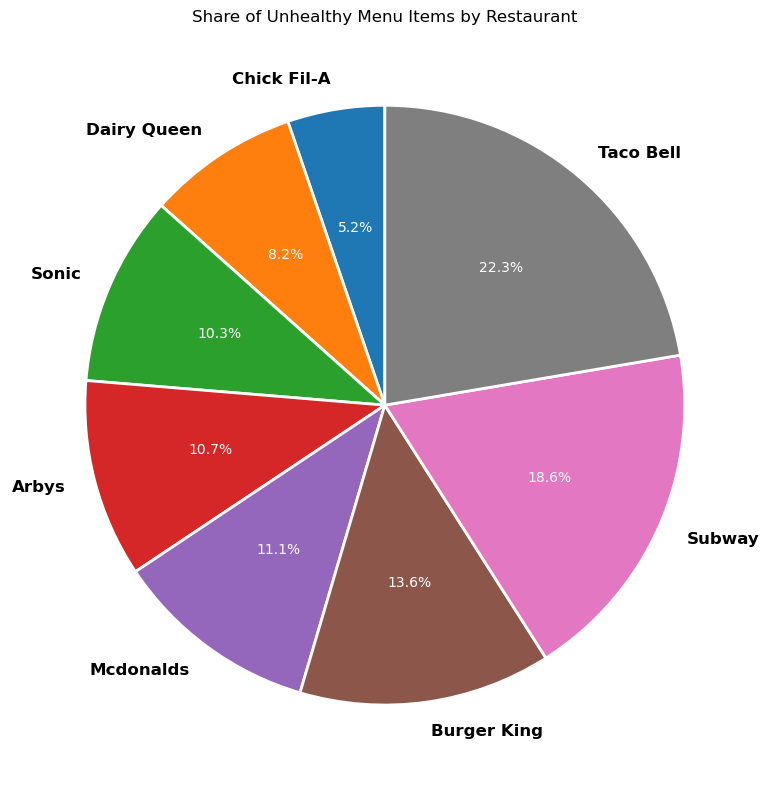

In [79]:
counts = unhealthy_counts.sort_values()

plt.figure(figsize=(8,8))

wedges, texts, autotexts = plt.pie(
    counts,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10}
)


for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize("10")

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight("bold")

plt.title("Share of Unhealthy Menu Items by Restaurant")
plt.tight_layout()
plt.show()

 # Fast Food Data

In [83]:
fastfood = pd.read_csv("archive (4).zip")

In [85]:
restaurants = ['McDonald’s', 'Chick-fil-A', 'Sonic Drive-In','Arby’s',
               'Burger King', 'Dairy Queen']

pop_filtered = fastfood[fastfood['Fast-Food Chains'].isin(restaurants)]
pop_filtered

,Fast-Food Chains,U.S. Systemwide Sales (Millions - U.S Dollars),Average Sales per Unit (Thousands - U.S Dollars),Franchised Stores,Company Stores,2021 Total Units,Total Change in Units from 2020
0,Arby’s,4462,1309,2293,1116,3409,40
3,Burger King,10033,1470,7054,51,7105,24
6,Chick-fil-A,16700,6100,2650,82,2732,155
10,Dairy Queen,4494,1036,4337,2,4339,-22
28,McDonald’s,45960,3420,12775,663,13438,244
39,Sonic Drive-In,5835,1643,3232,320,3552,26


In [87]:
op = pop_filtered[['Fast-Food Chains','U.S. Systemwide Sales (Millions - U.S Dollars)', 'Average Sales per Unit (Thousands - U.S Dollars)', '2021 Total Units' , 'Franchised Stores','Company Stores']]

In [103]:
revenue_plot = pop_filtered[
    [
        "Fast-Food Chains",
        "U.S. Systemwide Sales (Millions - U.S Dollars)",
        "Average Sales per Unit (Thousands - U.S Dollars)",
        "2021 Total Units"
    ]
]

revenue_plot = revenue_plot.set_index("Fast-Food Chains")
revenue_plot = revenue_plot / revenue_plot.max()

revenue_plot

,U.S. Systemwide Sales (Millions - U.S Dollars),Average Sales per Unit (Thousands - U.S Dollars),2021 Total Units
Fast-Food Chains,,,
Arby’s,0.097084,0.214590,0.253684
Burger King,0.218299,0.240984,0.528725
Chick-fil-A,0.363359,1.000000,0.203304
Dairy Queen,0.097781,0.169836,0.322890
McDonald’s,1.000000,0.560656,1.000000
Sonic Drive-In,0.126958,0.269344,0.264325


cite: I asked chatgpt to help show me different color pallets and how to increase the fonts to ensire my plot that can be easy to read and match the aesthetic of my slide.

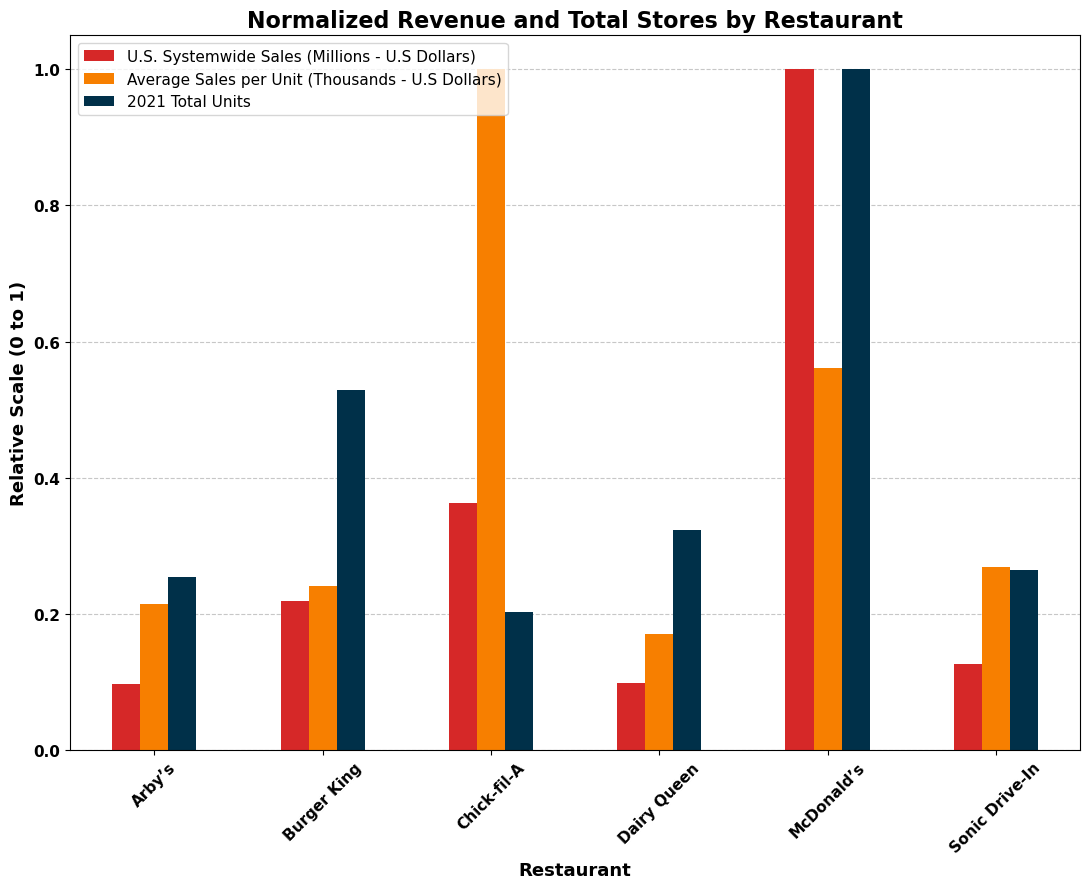

In [113]:
ax = revenue_plot.plot(
    kind="bar",
    figsize=(11,9),
    color=["#D62828", "#F77F00", "#003049"]
)

plt.title(
    "Normalized Revenue and Total Stores by Restaurant",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel(
    "Relative Scale (0 to 1)",
    fontsize=13,
    fontweight="bold"
)

plt.xlabel(
    "Restaurant",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(rotation=45, fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

plt.legend(fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.gca().set_axisbelow(True)

plt.tight_layout()
plt.savefig("nutrition_plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Comparison

Cite: For this part, I used chatgpt to help me with combining all the restraunts from the nutrition and revenue data sets.Even though all the restraunts was the same, they were written differently ( Ex Chick Fil-A vs Chik-Fil-A). I also asked chatgpt some recommadations for color pallets because I wanted the scatter plot to showase the restraunts colors.

In [120]:
avg_health_score = (
    nutrition.groupby("restaurant")["unhealthy_score"]
    .mean()
    .reset_index()
)

print(avg_health_score)

    restaurant  unhealthy_score
0        Arbys         5.410270
1  Burger King         5.207358
2  Chick Fil-A         4.409156
3  Dairy Queen         5.777525
4    Mcdonalds         4.727596
5        Sonic         5.943902
6       Subway         5.006278
7    Taco Bell         4.458774


In [136]:
avg_health_score["restaurant_clean"] = (
    avg_health_score["restaurant"]
    .str.lower()
    .str.replace("’", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.strip()
)

pop_filtered["restaurant_clean"] = (
    pop_filtered["Fast-Food Chains"]
    .str.lower()
    .str.replace("’", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.strip()
)

/var/folders/wb/v1snth757cq19y9gm2466m3c0000gn/T/ipykernel_1241/2346154780.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pop_filtered["restaurant_clean"] = (


In [138]:
print(avg_health_score["restaurant_clean"].unique())
print(pop_filtered["restaurant_clean"].unique())

['arbys' 'burger king' 'chick fil-a' 'dairy queen' 'mcdonalds' 'sonic'
 'subway' 'taco bell']
['arbys' 'burger king' 'chick-fil-a' 'dairy queen' 'mcdonalds'
 'sonic drive-in' 'subway' 'taco bell']


In [140]:
avg_health_score["restaurant_clean"] = avg_health_score["restaurant_clean"].replace({
    "chick fil-a": "chick-fil-a",
    "sonic": "sonic drive-in"
})

In [142]:
final_compare = avg_health_score.merge(
    pop_filtered,
    on="restaurant_clean",
    how="inner"
)

print(final_compare["restaurant_clean"])

0             arbys
1       burger king
2       chick-fil-a
3       dairy queen
4         mcdonalds
5    sonic drive-in
6            subway
7         taco bell
Name: restaurant_clean, dtype: object


In [144]:
final_compare["restaurant_clean"] = final_compare["restaurant_clean"].replace({
    "arbys": "Arby's",
    "burger king": "Burger King",
    "chick-fil-a": "Chick-fil-A",
    "dairy queen": "Dairy Queen",
    "mcdonalds": "McDonalds",
    "sonic drive-in": "Sonic Drive-In",
    "subway": "Subway",
    "taco bell": "Taco Bell"
})

final_compare = final_compare.rename(
    columns={"restaurant_clean": "Fast-Food Chains"}
)


In [146]:
wanted_restaurants = [
    "arbys",
    "burger king",
    "chick-fil-a",
    "dairy queen",
    "mcdonalds",
    "sonic drive-in",
    "subway",
    "taco bell"
]

fastfood["restaurant_clean"] = (
    fastfood["Fast-Food Chains"]
    .str.lower()
    .str.replace("’", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.strip()
)

fastfood["restaurant_clean"] = fastfood["restaurant_clean"].replace({
    "chick fil-a": "chick-fil-a",
    "sonic": "sonic drive-in"
})

pop_filtered = fastfood[fastfood["restaurant_clean"].isin(wanted_restaurants)]

In [150]:
print(final_compare.columns)

Index(['restaurant', 'unhealthy_score', 'Fast-Food Chains', 'Fast-Food Chains',
       'U.S. Systemwide Sales (Millions - U.S Dollars)',
       'Average Sales per Unit (Thousands - U.S Dollars)', 'Franchised Stores',
       'Company Stores', '2021 Total Units',
       'Total Change in Units from 2020'],
      dtype='object')


In [152]:
final_compare = final_compare.loc[:, ~final_compare.columns.duplicated()]

In [156]:
restaurant_hex = {
    "McDonalds": "#FFC72C",
    "Chick-fil-A": "#E51636",
    "Sonic Drive-In": "#1B3A8A",
    "Arby's": "#B22222",
    "Burger King": "#D62300",
    "Dairy Queen": "#E31937",
    "Subway": "#009A44",
    "Taco Bell": "#702082"
}

In [158]:
colors = [
    restaurant_hex[restaurant]
    for restaurant in final_compare["Fast-Food Chains"]
]

  Fast-Food Chains  unhealthy_score  \
0           Arby's         5.410270   
1      Burger King         5.207358   
2      Chick-fil-A         4.409156   
3      Dairy Queen         5.777525   
4        McDonalds         4.727596   
5   Sonic Drive-In         5.943902   
6           Subway         5.006278   
7        Taco Bell         4.458774   

   U.S. Systemwide Sales (Millions - U.S Dollars)  
0                                            4462  
1                                           10033  
2                                           16700  
3                                            4494  
4                                           45960  
5                                            5835  
6                                            9350  
7                                           12600  


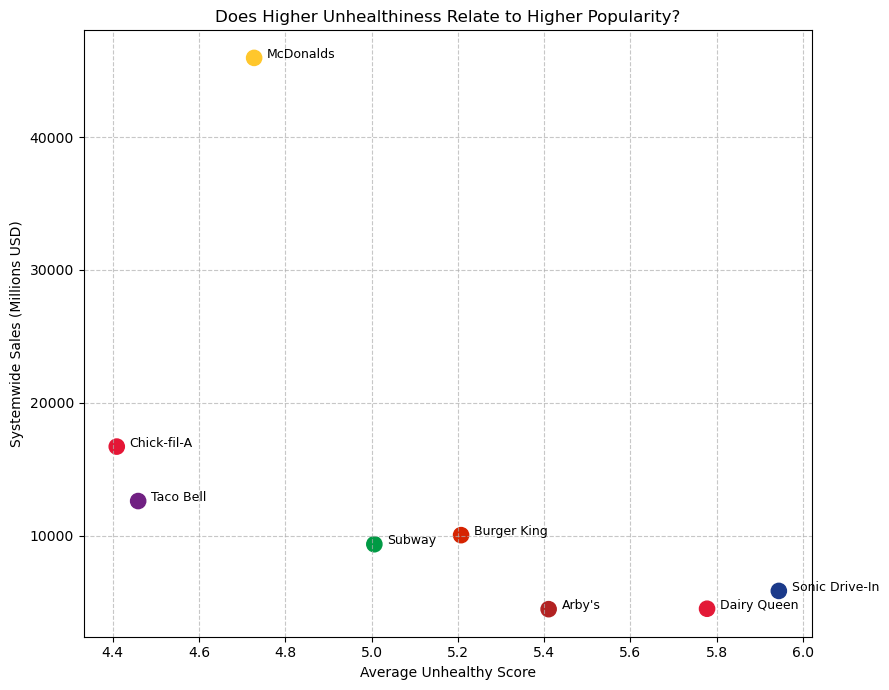

In [160]:
plt.figure(figsize=(9,7))

plt.scatter(
    final_compare["unhealthy_score"],
    final_compare["U.S. Systemwide Sales (Millions - U.S Dollars)"],
    s=120,
    c=colors
)

for i, row in final_compare.iterrows():
    plt.text(
        row["unhealthy_score"] + 0.03,
        row["U.S. Systemwide Sales (Millions - U.S Dollars)"],
        row["Fast-Food Chains"],
        fontsize=9
    )

plt.xlabel("Average Unhealthy Score")
plt.ylabel("Systemwide Sales (Millions USD)")
plt.title("Does Higher Unhealthiness Relate to Higher Popularity?")
plt.grid(True, linestyle="--", alpha=0.7)
plt.savefig("nutrition_pllt.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
print(final_compare[[
    "Fast-Food Chains",
    "unhealthy_score",
    "U.S. Systemwide Sales (Millions - U.S Dollars)"
]])
plt.show()